In [1]:
# going to use the same data set jo pichle (Z_score) mae use kara 

In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('placement.csv')

In [4]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


<Axes: xlabel='placement_exam_marks', ylabel='Count'>

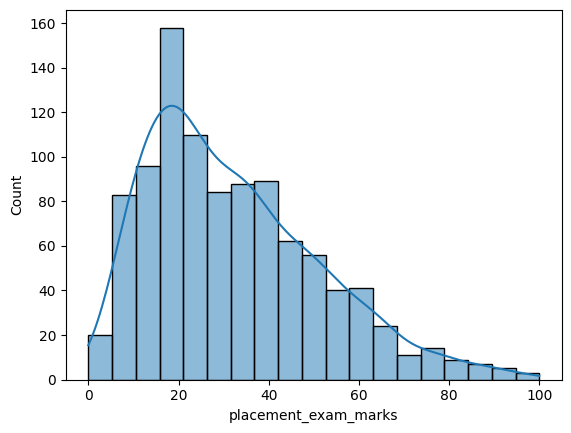

In [7]:
sns.histplot(df['placement_exam_marks'], kde = True)

In [6]:
import seaborn as sns

In [8]:
# since its a skewed data so we are gonna use box plot method to detect and remove the outlier

In [10]:
# finding skewness
df['cgpa'].skew()

np.float64(-0.014529938929314918)

In [11]:
df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

In [14]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

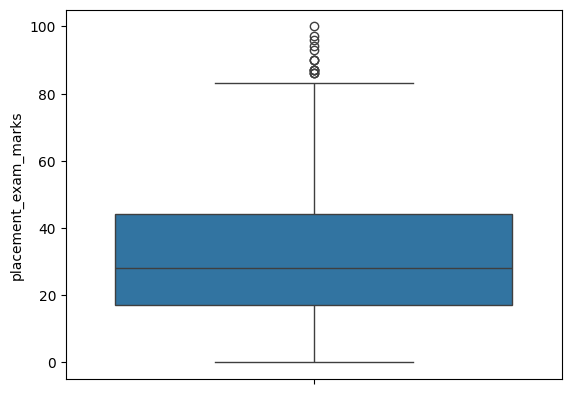

In [15]:
sns.boxplot(df['placement_exam_marks'])

In [16]:
# sabse pehle finding iqr
percentile_25 = df['placement_exam_marks'].quantile(0.25)

In [17]:
percentile_75 = df['placement_exam_marks'].quantile(0.75)

In [18]:
iqr = percentile_75 - percentile_25

In [21]:
print(f'The 25th percentile is {percentile_25}')
print(f'The 75th percentile is {percentile_75}')
print(f'The IQR is {iqr}')

The 25th percentile is 17.0
The 75th percentile is 44.0
The IQR is 27.0


In [22]:
upper_limit = percentile_75 + 1.5 * iqr

In [23]:
lower_limit = percentile_25 - 1.5 * iqr

In [24]:
print(f'the upper limit is {upper_limit}')
print(f'the lower limit is {lower_limit}')

the upper limit is 84.5
the lower limit is -23.5


In [25]:
# outliers 

In [26]:
df[df['placement_exam_marks'] > upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [28]:
df[df['placement_exam_marks'] > upper_limit].shape

(15, 3)

In [29]:
# teimmming 

In [30]:
new_trim = df[df['placement_exam_marks'] < upper_limit]

In [31]:
new_trim

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


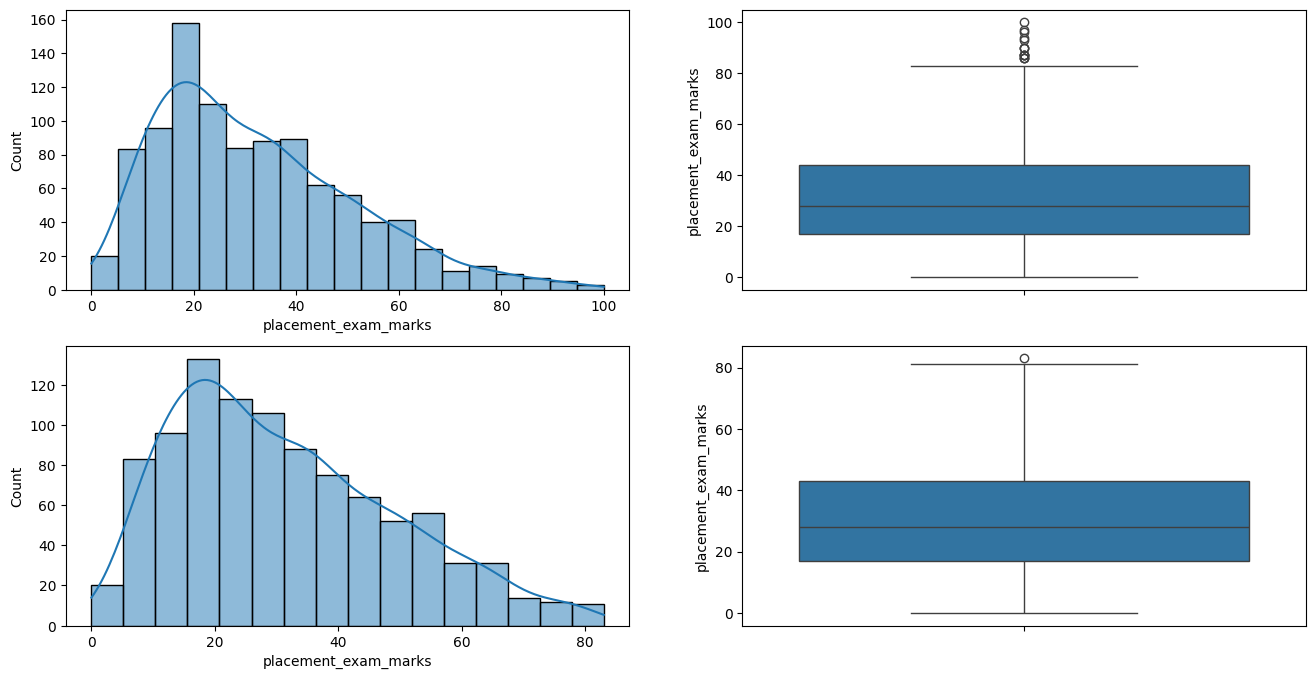

In [36]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.histplot(df['placement_exam_marks'], kde = True)
plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])
plt.subplot(2,2,3)
sns.histplot(new_trim['placement_exam_marks'], kde = True)
plt.subplot(2,2,4)
sns.boxplot(new_trim['placement_exam_marks'])
plt.show()

In [33]:
import matplotlib.pyplot as plt

In [37]:
# eek outlier 

In [48]:
percentile_75_eek = new_trim['placement_exam_marks'].quantile(0.75)

In [49]:
percentile_25_eek = new_trim['placement_exam_marks'].quantile(0.25)

In [50]:
upper_limit_eek = percentile_75_eek + 1.5 * iqr
lower_limit_eek = percentile_25_eek - 1.5 * iqr

In [51]:
print(upper_limit_eek)
print(lower_limit_eek)

83.5
-23.5


In [57]:
new_trim[new_trim['placement_exam_marks'] > upper_limit_eek]

,cgpa,placement_exam_marks,placed


In [59]:
new_trim[new_trim['placement_exam_marks'] < lower_limit_eek]

,cgpa,placement_exam_marks,placed


In [60]:
# unnable to find that one outler

In [61]:
# capping

In [62]:
new_df_cap = df.copy()

In [63]:
new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap['placement_exam_marks'] < lower_limit,
        lower_limit,
        new_df_cap['placement_exam_marks']
    )
)

In [64]:
new_df_cap.shape

(1000, 3)

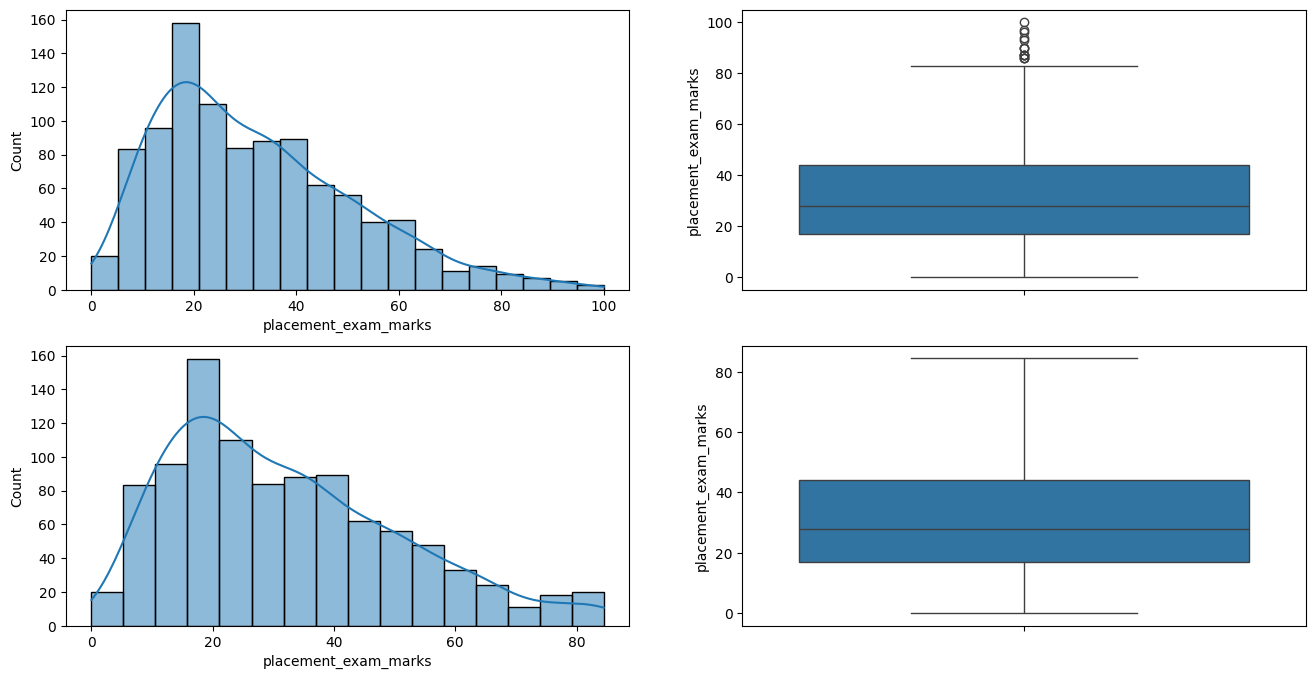

In [66]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.histplot(df['placement_exam_marks'], kde = True)
plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])
plt.subplot(2,2,3)
sns.histplot(new_df_cap['placement_exam_marks'], kde = True)
plt.subplot(2,2,4)
sns.boxplot(new_df_cap['placement_exam_marks'])
plt.show()